In [1]:
import os
import pickle
import scanpy as sc
import numpy as np
import pyranges as pr
import pandas as pd
import anndata as ad
from gtfparse import read_gtf
data_dir = '/hdd/jupyter/brad/scenicplus/motor-pathway_multiome/motor-pathway_multiome_seurat_cellbender.0.05_preprocess_cr/data/'
work_dir = '/hdd/jupyter/brad/scenicplus/motor-pathway_multiome/motor-pathway_multiome_seurat_cellbender.0.05_preprocess_cr/ra-arco-hvc-nc_seurat-snrna-clustering/anndata_rna/'
tmp_dir = '/tmp/motor-pathway_multiome'
adata_fname = os.path.join(data_dir, "adata.h5ad")
adata_out_fname = os.path.join(work_dir, 'adata.h5ad')

## snRNA-seq

In [2]:
adata = sc.read_h5ad(adata_fname)

In [3]:
adata

AnnData object with n_obs × n_vars = 17334 × 15948
    obs: 'cluster', 'position', 'assignment', 'sample_short', 'run', 'replicate'
    var: 'name'
    obsm: 'X_umap_rna_int'

In [4]:
"""
adata_filt = adata[adata.obs.cluster.str.contains('Glut')]
adata_filt = adata_filt[~adata_filt.obs.cluster.str.contains('IP|NB|NP')]
adata_filt = adata_filt[~adata_filt.obs.cluster.str.contains('GABA')]
adata_filt = adata_filt[~adata_filt.obs.cluster.str.contains('NC|HVC')]
adata_filt = adata_filt[~adata_filt.obs.sample_short.str.contains('run3')]
adata_filt = adata_filt[adata_filt.obs.sample_short.str.contains('ra|arco')]
adata = adata_filt
"""

"\nadata_filt = adata[adata.obs.cluster.str.contains('Glut')]\nadata_filt = adata_filt[~adata_filt.obs.cluster.str.contains('IP|NB|NP')]\nadata_filt = adata_filt[~adata_filt.obs.cluster.str.contains('GABA')]\nadata_filt = adata_filt[~adata_filt.obs.cluster.str.contains('NC|HVC')]\nadata_filt = adata_filt[~adata_filt.obs.sample_short.str.contains('run3')]\nadata_filt = adata_filt[adata_filt.obs.sample_short.str.contains('ra|arco')]\nadata = adata_filt\n"

In [5]:

cluster_var = 'cluster'
cell_data = adata.obs
cell_data[cluster_var] = cell_data[cluster_var].astype(str) # set data type of the celltype column to str, otherwise the export_pseudobulk function will complain.
cell_data[cluster_var] = cell_data[cluster_var].astype(str)
cell_data[cluster_var]


AAACAGCCACACAATT-1       GABA-Pre
AAACCGAAGTTATGTG-1    Glut-Nido-3
AAACCGCGTTTAGCGA-1       GABA-2-1
AAACGCGCAGTAAAGC-1        Astro-2
AAACGCGCATAATGAG-1     Glut-Pre-3
                         ...     
TTTGTGTTCGCTTCTA-8    Glut-Arco-7
TTTGTTGGTAACGGGA-8    Glut-Arco-1
TTTGTTGGTAGTTGGC-8    Glut-Arco-1
TTTGTTGGTCATGCAA-8    Glut-Arco-1
TTTGTTGGTCCGTGAG-8       GABA-4-1
Name: cluster, Length: 17334, dtype: object

In [6]:
adata.obs[cluster_var].unique()

array(['GABA-Pre', 'Glut-Nido-3', 'GABA-2-1', 'Astro-2', 'Glut-Pre-3',
       'GABA-1-1', 'Glut-Pre-2', 'GABA-3', 'Glut-NC-4', 'OPC',
       'Glut-HVC-1', 'Glut-HVC-2', 'Glut-Pre-1', 'Glut-NC-1', 'GABA-1-2',
       'Oligo', 'Epen', 'Glut-NC-2', 'GABA-4-1', 'GABA-6', 'GABA-5',
       'Astro-1', 'GABA-8', 'Micro', 'Glut-NC-3', 'Endo', 'Glut-Arco-6',
       'Glut-Arco-1', 'Glut-Arco-2', 'Glut-RA', 'Glut-Arco-7'],
      dtype=object)

In [7]:
adata.obsm['archr_umap'] = adata.obsm['X_umap_rna_int']

In [8]:
adata.raw = adata
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)

/home/brad/micromamba/envs/scenicplus/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Revieved a view of an AnnData. Making a copy.
  view_to_actual(adata)


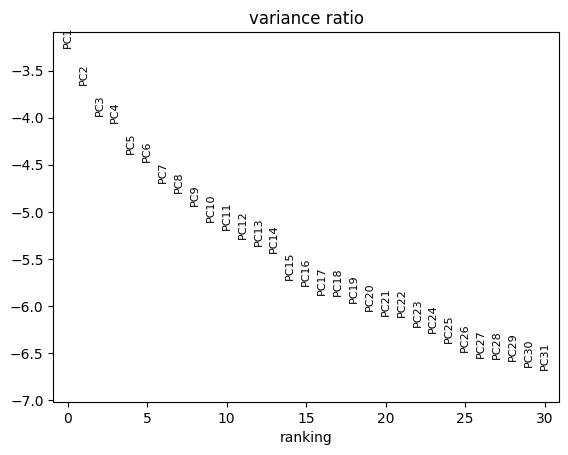

In [9]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True)

In [10]:
adata.obsm['X_umap_rna_int']

array([[ 11.4961218 ,  -0.97080796],
       [ -2.51721987,  -4.60295563],
       [ 11.86822167,  -0.98902565],
       ...,
       [ -9.08872374,   2.40032906],
       [-10.72937735,   1.90112752],
       [ 10.42456952,  -3.96540671]])

... storing 'cluster' as categorical
/home/brad/micromamba/envs/scenicplus/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


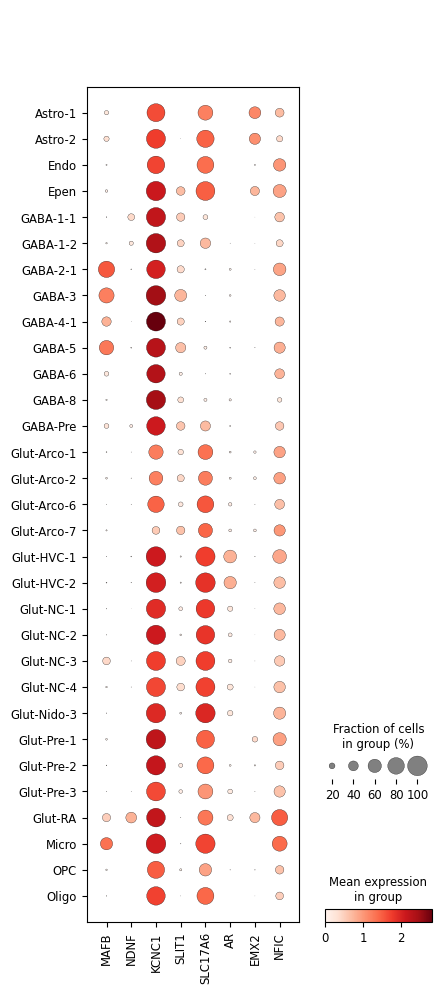

In [11]:
sc.pl.dotplot(adata, var_names=['MAFB', 'NDNF', 'KCNC1', 'SLIT1', 'SLC17A6','AR', 'EMX2', 'NFIC'], groupby=cluster_var)

/home/brad/micromamba/envs/scenicplus/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/brad/micromamba/envs/scenicplus/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


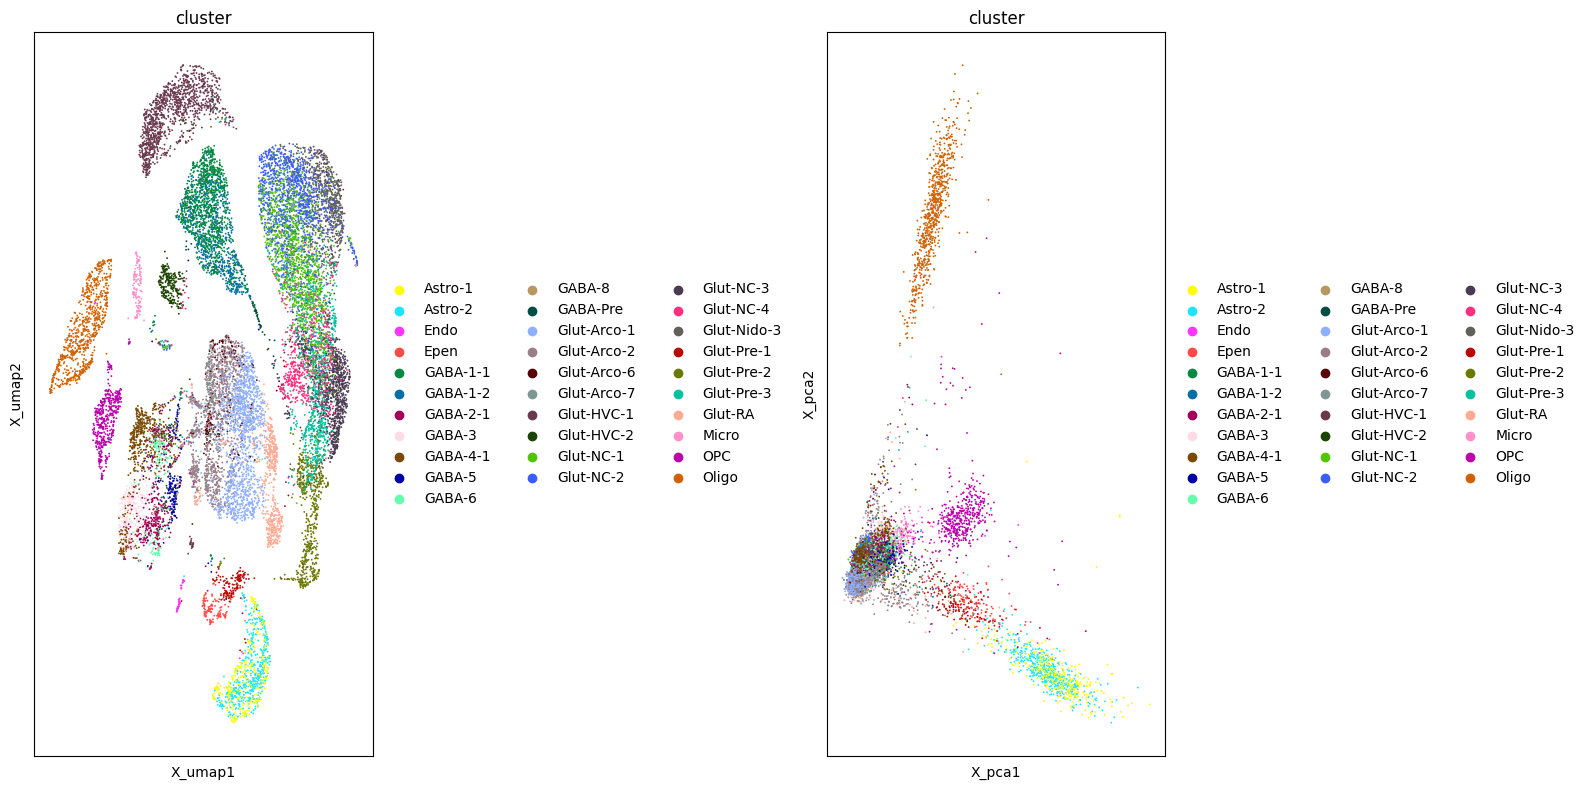

In [12]:
import matplotlib.pyplot as plt

sc.pp.neighbors(adata, n_neighbors=10, n_pcs=10)
sc.tl.umap(adata)

fig, axs = plt.subplots(ncols = 2, figsize = (16,8))
sc.pl.embedding(adata, basis='X_umap', ax=axs[0], color = cluster_var, show=False)
sc.pl.embedding(adata, basis='X_pca', ax=axs[1], color = cluster_var, show=False)
fig.tight_layout()
plt.show()

/home/brad/micromamba/envs/scenicplus/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


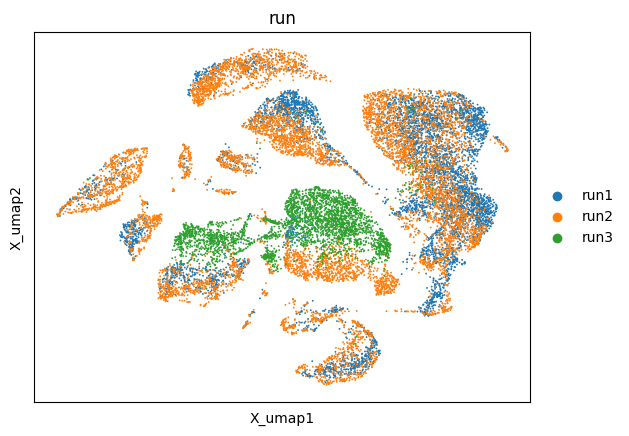

In [13]:
sc.pl.embedding(adata, basis='X_umap', color = 'run', show=True)

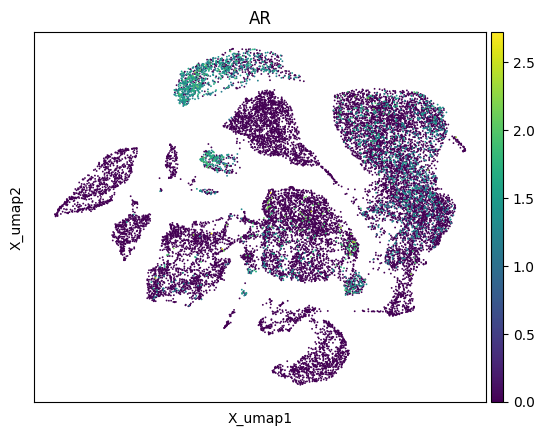

In [14]:
sc.pl.embedding(adata, basis='X_umap', color = 'AR', show=True)

In [15]:
### Fix cell_data cell name to match cisTopic object
cell_data_mod = adata.obs.copy()
cell_data_mod.index = cell_data_mod.index.str.replace("-[0-9]", "-1", regex=True)
indices = cell_data_mod.index.to_list()
cell_data_mod["barcode"] = cell_data_mod.index
out = cell_data_mod.apply(lambda x: '___'.join([x.barcode, f"{x.sample_short}"]), axis=1)
cell_data_mod.index = out
adata.obs = cell_data_mod
print(adata.obs)

                                    cluster position assignment sample_short  \
AAACAGCCACACAATT-1___hvc_run1      GABA-Pre      hvc          2     hvc_run1   
AAACCGAAGTTATGTG-1___hvc_run1   Glut-Nido-3      hvc          2     hvc_run1   
AAACCGCGTTTAGCGA-1___hvc_run1      GABA-2-1      hvc          2     hvc_run1   
AAACGCGCAGTAAAGC-1___hvc_run1       Astro-2      hvc          2     hvc_run1   
AAACGCGCATAATGAG-1___hvc_run1    Glut-Pre-3      hvc          2     hvc_run1   
...                                     ...      ...        ...          ...   
TTTGTGTTCGCTTCTA-1___arco_run3  Glut-Arco-7     arco          0    arco_run3   
TTTGTTGGTAACGGGA-1___arco_run3  Glut-Arco-1     arco          2    arco_run3   
TTTGTTGGTAGTTGGC-1___arco_run3  Glut-Arco-1     arco          3    arco_run3   
TTTGTTGGTCATGCAA-1___arco_run3  Glut-Arco-1     arco          0    arco_run3   
TTTGTTGGTCCGTGAG-1___arco_run3     GABA-4-1     arco          3    arco_run3   

                                 run re

In [16]:
adata.write_h5ad(adata_out_fname)

... storing 'barcode' as categorical
